# Analiza danych o wypadkach samochodowych w Nowym Jorku

W tym notebooku robię analizę danych po czyszczeniu. Układ jest zgodny z punktami z pliku `docs/informacje_o_projekcie_zaliczeniowym`.

Dane są wcześniej przygotowane w notebooku `czyszczenie_danych_2.ipynb`. Tutaj korzystam już z gotowych plików po czyszczeniu.


## Założenia

Korzystam z dwóch plików:

- `dane_przetworzone_2.csv` - jeden wiersz to jeden wypadek,
- `dane_pojazdy_przyczyny_2.csv` - pomocniczy plik do analizy pojazdów i czynników.

W danych nie ma jednoznacznej informacji, kto był sprawcą wypadku. Dlatego jeśli jakiś czynnik pojawia się przy którymkolwiek pojeździe, liczę ten wypadek jako związany z tym czynnikiem.


In [1]:
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="Set2")

DATA_DIR: Path = Path("data")
CLEAN_PATH: Path = DATA_DIR / "dane_przetworzone_2.csv"
LONG_PATH: Path = DATA_DIR / "dane_pojazdy_przyczyny_2.csv"
QUALITY_REPORT_PATH: Path = DATA_DIR / "raport_czyszczenia_2.csv"

required_files: list[Path] = [CLEAN_PATH, LONG_PATH, QUALITY_REPORT_PATH]
missing_files: list[str] = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Brakuje plików po czyszczeniu: " + ", ".join(missing_files)
        + ". Najpierw uruchom `czyszczenie_danych_2.ipynb`."
    )

BOROUGHS: list[str] = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]


In [2]:
accidents: pd.DataFrame = pd.read_csv(CLEAN_PATH, low_memory=False, parse_dates=["ACCIDENT_DATE_CLEAN", "ACCIDENT_DATETIME"])
vehicle_factors: pd.DataFrame = pd.read_csv(LONG_PATH, low_memory=False, parse_dates=["ACCIDENT_DATE_CLEAN", "ACCIDENT_DATETIME"])
quality_report: pd.DataFrame = pd.read_csv(QUALITY_REPORT_PATH)

accidents_borough: pd.DataFrame = accidents.loc[accidents["BOROUGH"].notna()].copy()
vehicle_factors["CONTRIBUTING FACTOR"] = vehicle_factors["CONTRIBUTING FACTOR"].fillna("EMPTY")

factor_mentions: pd.DataFrame = vehicle_factors.loc[vehicle_factors["CONTRIBUTING FACTOR"].ne("EMPTY")].copy()
real_factor_mentions: pd.DataFrame = factor_mentions.loc[factor_mentions["CONTRIBUTING FACTOR"].ne("UNSPECIFIED")].copy()

# Deduplicacja na poziomie wypadek + czynnik, aby jeden wypadek nie był liczony kilka razy dla tego samego czynnika.
factor_accidents: pd.DataFrame = factor_mentions.drop_duplicates(["COLLISION_ID", "BOROUGH", "CONTRIBUTING FACTOR"])
real_factor_accidents: pd.DataFrame = real_factor_mentions.drop_duplicates(["COLLISION_ID", "BOROUGH", "CONTRIBUTING FACTOR"])

vehicle_rows: pd.DataFrame = vehicle_factors.loc[vehicle_factors["VEHICLE TYPE"].notna()].copy()
known_vehicle_rows: pd.DataFrame = vehicle_rows.loc[vehicle_rows["VEHICLE TYPE"].ne("UNKNOWN/OTHER")].copy()

print("Wypadki po czyszczeniu:", f"{len(accidents):,}".replace(",", " "))
print("Unikalne COLLISION_ID:", f"{accidents['COLLISION_ID'].nunique():,}".replace(",", " "))
print("Wiersze pojazd/czynnik:", f"{len(vehicle_factors):,}".replace(",", " "))
print("Zakres dat:", accidents["ACCIDENT_DATE_CLEAN"].min().date(), "-", accidents["ACCIDENT_DATE_CLEAN"].max().date())


Wypadki po czyszczeniu: 1 217 634
Unikalne COLLISION_ID: 1 217 634
Wiersze pojazd/czynnik: 2 435 927
Zakres dat: 2012-07-01 - 2019-11-26


## 3.1. Sprawdzenie, opisanie i przygotowanie danych

Najpierw pokazuję podstawowe informacje o danych po czyszczeniu. Sam proces czyszczenia jest dokładniej pokazany w notebooku `czyszczenie_danych_2.ipynb`.


In [3]:
display(quality_report)

basic_summary: pd.DataFrame = pd.DataFrame(
    {
        "metryka": [
            "liczba wypadków po czyszczeniu",
            "unikalne COLLISION_ID",
            "liczba kolumn w tabeli wypadków",
            "suma rannych",
            "suma zabitych",
            "rekordy z dzielnicą",
            "rekordy bez dzielnicy",
            "rekordy z poprawnymi współrzędnymi",
            "rekordy bez poprawnych współrzędnych",
            "liczba znanych typów pojazdów",
            "liczba merytorycznych czynników",
        ],
        "wartość": [
            len(accidents),
            accidents["COLLISION_ID"].nunique(),
            accidents.shape[1],
            int(accidents["NUMBER OF PERSONS INJURED"].sum()),
            int(accidents["NUMBER OF PERSONS KILLED"].sum()),
            int(accidents["BOROUGH"].notna().sum()),
            int(accidents["BOROUGH"].isna().sum()),
            int((~accidents["brak_wspolrzednych"]).sum()),
            int(accidents["brak_wspolrzednych"].sum()),
            known_vehicle_rows["VEHICLE TYPE"].nunique(),
            real_factor_accidents["CONTRIBUTING FACTOR"].nunique(),
        ],
    }
)
display(basic_summary)


,krok,liczba_wierszy_przed,liczba_wierszy_po,usuniete_wiersze,opis
0,Dane wejściowe,1612178,1612178,0,Oryginalny plik CSV przed czyszczeniem
1,Usunięcie dokładnych duplikatów,1612178,1217957,394221,Usunięto 394 221 identycznych wierszy
2,Usunięcie niespójnych rekordów obrażeń/zgonów,1217957,1217634,323,Kontrola sum cząstkowych i łącznych


,metryka,wartość
0,liczba wypadków po czyszczeniu,1217634
1,unikalne COLLISION_ID,1217634
2,liczba kolumn w tabeli wypadków,44
3,suma rannych,320164
4,suma zabitych,1411
5,rekordy z dzielnicą,940474
6,rekordy bez dzielnicy,277160
7,rekordy z poprawnymi współrzędnymi,1070154
8,rekordy bez poprawnych współrzędnych,147480
9,liczba znanych typów pojazdów,436


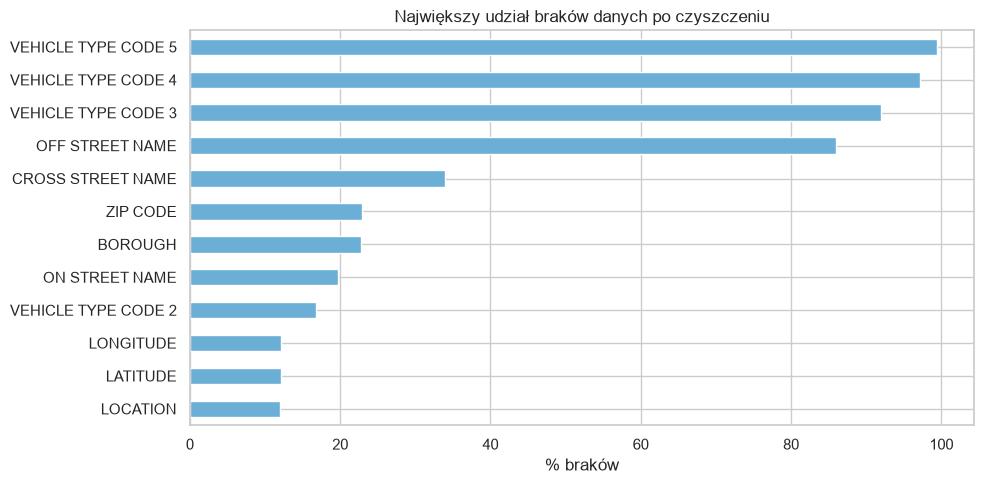

,% braków
VEHICLE TYPE CODE 5,99.373539
VEHICLE TYPE CODE 4,97.138221
VEHICLE TYPE CODE 3,92.022069
OFF STREET NAME,85.915144
CROSS STREET NAME,33.949036
ZIP CODE,22.957884
BOROUGH,22.762176
ON STREET NAME,19.733023
VEHICLE TYPE CODE 2,16.746658
LATITUDE,12.112014


In [4]:
missing_share: pd.Series = accidents.isna().mean().mul(100).sort_values(ascending=False).head(12).rename("% braków")

fig, ax = plt.subplots(figsize=(10, 5))
missing_share.sort_values().plot(kind="barh", ax=ax, color="#6BAED6")
ax.set_title("Największy udział braków danych po czyszczeniu")
ax.set_xlabel("% braków")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(missing_share.to_frame())


,liczba_wystąpień
merytoryczne czynniki,948905
UNSPECIFIED,1418202
EMPTY,68820


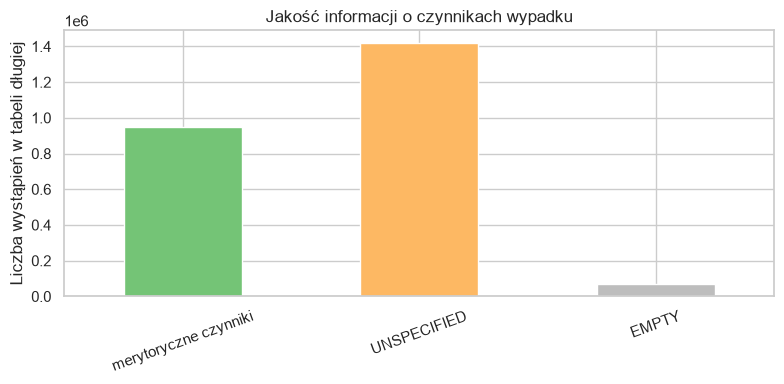

In [5]:
factor_quality: pd.Series = pd.Series(
    {
        "merytoryczne czynniki": int(vehicle_factors["CZYNNIK_MERYTORYCZNY"].sum()),
        "UNSPECIFIED": int(vehicle_factors["CONTRIBUTING FACTOR"].eq("UNSPECIFIED").sum()),
        "EMPTY": int(vehicle_factors["CONTRIBUTING FACTOR"].eq("EMPTY").sum()),
    }
).rename("liczba_wystąpień")

display(factor_quality.to_frame())

fig, ax = plt.subplots(figsize=(8, 4))
factor_quality.plot(kind="bar", ax=ax, color=["#74C476", "#FDB863", "#BDBDBD"])
ax.set_title("Jakość informacji o czynnikach wypadku")
ax.set_xlabel("")
ax.set_ylabel("Liczba wystąpień w tabeli długiej")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### Wniosek z przygotowania danych

W danych było dużo duplikatów. Usunięto **394 221** dokładnych powtórzeń wierszy. Usunięto też **323** rekordy, w których liczba rannych lub zabitych nie zgadzała się z kolumnami szczegółowymi.

Dużym problemem jest też kategoria `UNSPECIFIED`, czyli brak konkretnej przyczyny wypadku. Dlatego w dalszej analizie pokazuję wyniki tak, żeby puste lub nieokreślone wartości nie zaburzały głównych wniosków.


### Jak liczę wyniki

- Liczba wypadków to liczba unikalnych `COLLISION_ID`.
- `EMPTY` oznacza pusty slot i nie traktuję tego jako przyczyny.
- `UNSPECIFIED` pokazuję w tabelach, ale przy interpretacji często patrzę też na wersję bez tej kategorii.
- Jeśli ten sam czynnik pojawił się kilka razy w jednym wypadku, liczę go tylko raz dla tego wypadku.


## 3.2. Najniebezpieczniejsze czynniki wypadków w każdej dzielnicy

Tutaj sprawdzam, dla których czynników było najwięcej rannych i zabitych w przeliczeniu na 100 wypadków. Pomijam `UNSPECIFIED`, bo nie jest konkretną przyczyną.


In [6]:
danger_by_factor: pd.DataFrame = (
    real_factor_accidents.loc[real_factor_accidents["BOROUGH"].notna()]
    .groupby(["BOROUGH", "CONTRIBUTING FACTOR"])
    .agg(
        liczba_wypadkow=("COLLISION_ID", "nunique"),
        ranni=("NUMBER OF PERSONS INJURED", "sum"),
        zabici=("NUMBER OF PERSONS KILLED", "sum"),
    )
    .reset_index()
)
danger_by_factor["poszkodowani"] = danger_by_factor["ranni"] + danger_by_factor["zabici"]
danger_by_factor["poszkodowani_na_100_wypadkow"] = (
    danger_by_factor["poszkodowani"] / danger_by_factor["liczba_wypadkow"] * 100
)

danger_filtered: pd.DataFrame = danger_by_factor.loc[danger_by_factor["liczba_wypadkow"].ge(50)].copy()
top_danger_by_borough: pd.DataFrame = (
    danger_filtered.sort_values(["BOROUGH", "poszkodowani_na_100_wypadkow"], ascending=[True, False])
    .groupby("BOROUGH")
    .head(5)
)
top_danger_one: pd.DataFrame = top_danger_by_borough.groupby("BOROUGH").head(1).reset_index(drop=True)

display(top_danger_one)
display(top_danger_by_borough)


,BOROUGH,CONTRIBUTING FACTOR,liczba_wypadkow,ranni,zabici,poszkodowani,poszkodowani_na_100_wypadkow
0,BRONX,PHYSICAL DISABILITY,635,496,2,498,78.425197
1,BROOKLYN,PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CO...,1436,1094,7,1101,76.671309
2,MANHATTAN,PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CO...,1400,954,13,967,69.071429
3,QUEENS,PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CO...,601,477,11,488,81.198003
4,STATEN ISLAND,ILLNESS,66,46,1,47,71.212121


,BOROUGH,CONTRIBUTING FACTOR,liczba_wypadkow,ranni,zabici,poszkodowani,poszkodowani_na_100_wypadkow
36,BRONX,PHYSICAL DISABILITY,635,496,2,498,78.425197
35,BRONX,PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CO...,762,585,7,592,77.690289
11,BRONX,DRUGS (ILLEGAL),99,76,0,76,76.767677
46,BRONX,TRAFFIC CONTROL DISREGARDED,2383,1666,14,1680,70.499371
49,BRONX,UNSAFE SPEED,1602,1058,9,1067,66.604245
89,BROOKLYN,PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CO...,1436,1094,7,1101,76.671309
90,BROOKLYN,PHYSICAL DISABILITY,2120,1481,10,1491,70.330189
99,BROOKLYN,TRAFFIC CONTROL DEVICE IMPROPER/NON-WORKING,128,90,0,90,70.312500
100,BROOKLYN,TRAFFIC CONTROL DISREGARDED,5410,3607,35,3642,67.319778
103,BROOKLYN,UNSAFE SPEED,2825,1793,21,1814,64.212389


C:\Users\piotr\PycharmProjects\PracaDyplomowaAnalitykaDanych\.venv\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


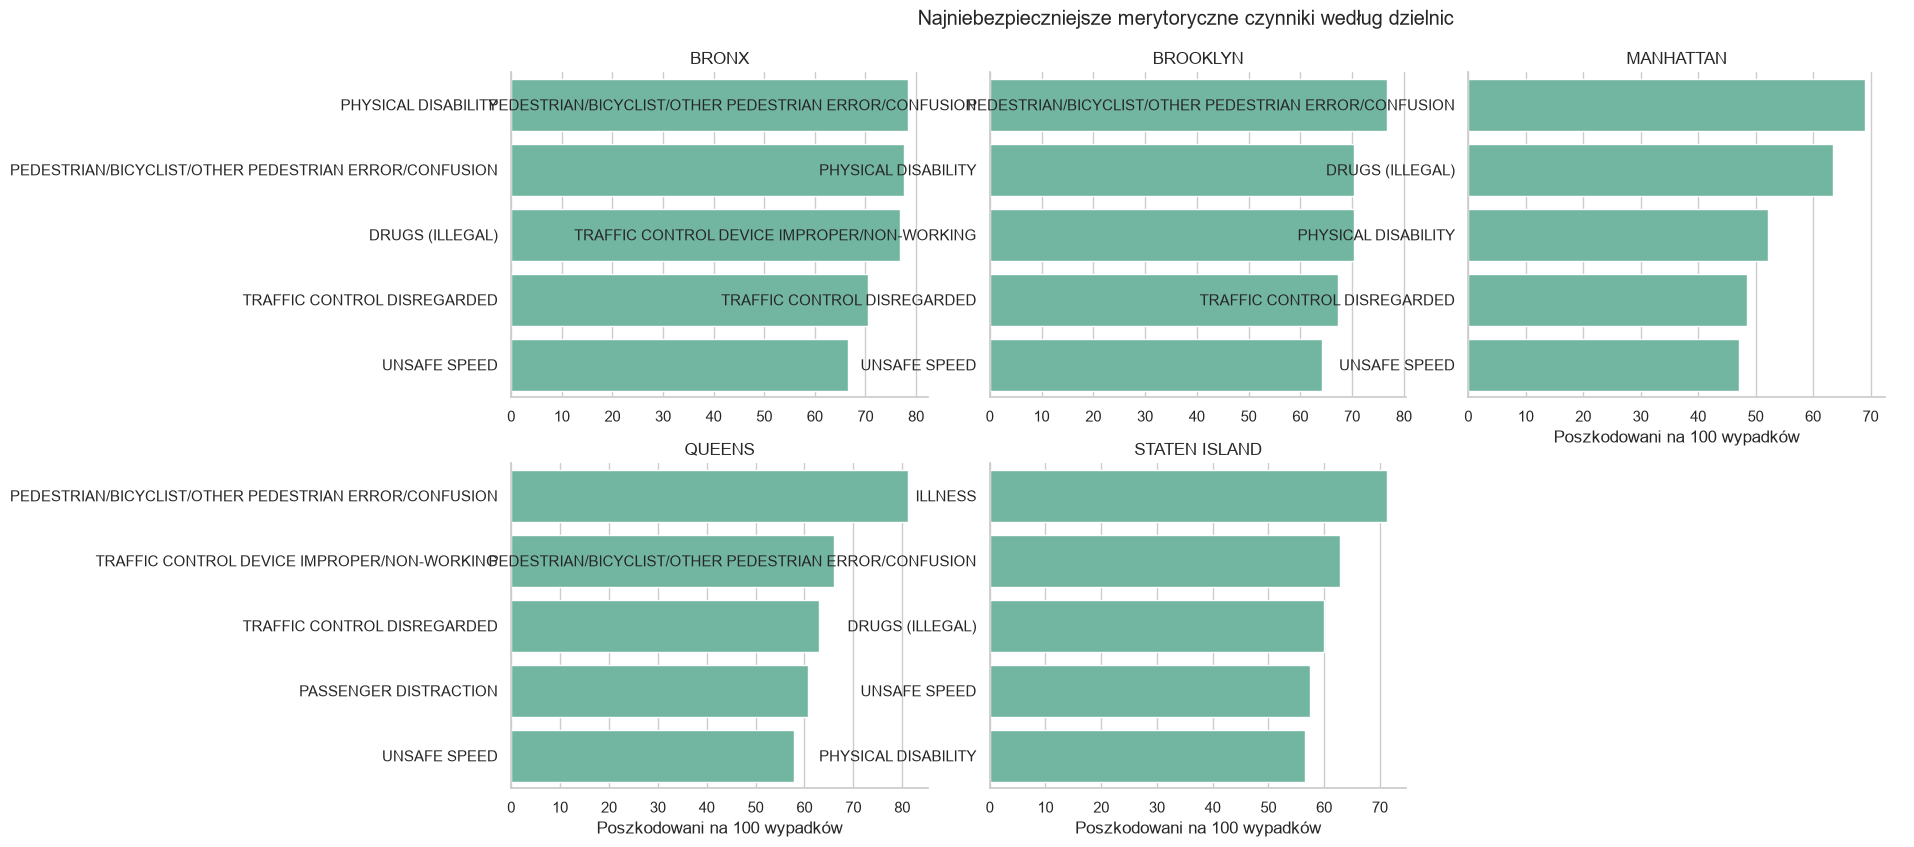

In [7]:
g = sns.catplot(
    data=top_danger_by_borough,
    kind="bar",
    x="poszkodowani_na_100_wypadkow",
    y="CONTRIBUTING FACTOR",
    col="BOROUGH",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=4,
    aspect=1.2,
)
g.set_titles("{col_name}")
g.set_axis_labels("Poszkodowani na 100 wypadków", "")
g.fig.suptitle("Najniebezpieczniejsze merytoryczne czynniki według dzielnic", y=1.03)
plt.show()


### Wniosek do punktu 3.2

Najniebezpieczniejsze czynniki nie są identyczne w każdej dzielnicy. W kilku dzielnicach wysoko pojawia się czynnik związany z błędem pieszego, rowerzysty lub innego uczestnika ruchu.

- **BRONX**: `PHYSICAL DISABILITY` - **78,4** poszkodowanych na 100 wypadków.
- **BROOKLYN**: `PEDESTRIAN/BICYCLIST/OTHER PEDESTRIAN ERROR/CONFUSION` - **76,7** poszkodowanych na 100 wypadków.
- **MANHATTAN**: ten sam czynnik - **69,1** poszkodowanych na 100 wypadków.
- **QUEENS**: ten sam czynnik - **81,2** poszkodowanych na 100 wypadków.
- **STATEN ISLAND**: `ILLNESS` - **71,2** poszkodowanych na 100 wypadków.


## 3.3. Zgony i obrażenia spowodowane przez szybką jazdę w danej dzielnicy

Szybka jazda występuje w danych jako `UNSAFE SPEED`.


,liczba_wypadkow,ranni,zabici,poszkodowani
BOROUGH,,,,
BROOKLYN,2825,1793,21,1814
QUEENS,2644,1497,33,1530
BRONX,1602,1058,9,1067
MANHATTAN,1143,535,4,539
STATEN ISLAND,445,253,3,256


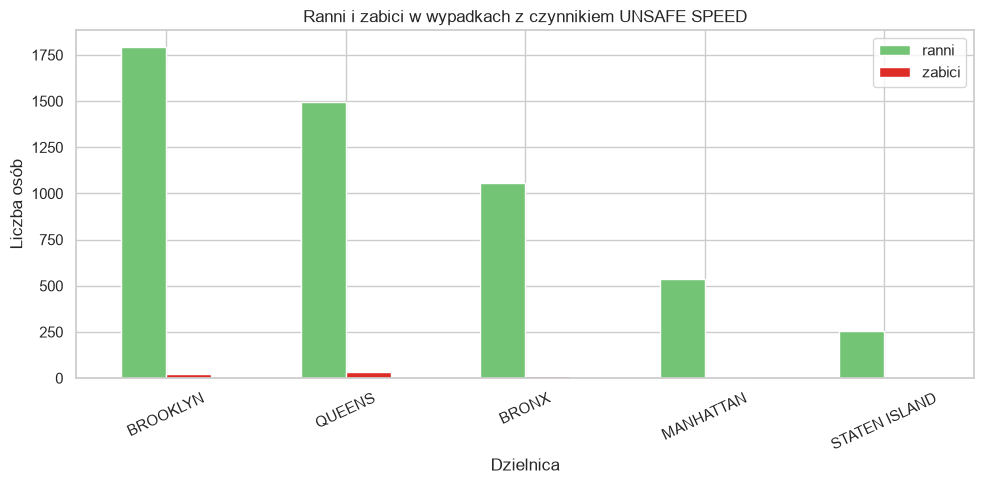

In [8]:
speed_collision_ids: list[object] = factor_mentions.loc[
    factor_mentions["CONTRIBUTING FACTOR"].eq("UNSAFE SPEED"), "COLLISION_ID"
].unique().tolist()

speed_accidents: pd.DataFrame = accidents_borough.loc[accidents_borough["COLLISION_ID"].isin(speed_collision_ids)].copy()
speed_by_borough: pd.DataFrame = (
    speed_accidents.groupby("BOROUGH")
    .agg(
        liczba_wypadkow=("COLLISION_ID", "nunique"),
        ranni=("NUMBER OF PERSONS INJURED", "sum"),
        zabici=("NUMBER OF PERSONS KILLED", "sum"),
    )
    .reindex(BOROUGHS)
    .fillna(0)
    .astype(int)
)
speed_by_borough["poszkodowani"] = speed_by_borough["ranni"] + speed_by_borough["zabici"]
speed_by_borough = speed_by_borough.sort_values("poszkodowani", ascending=False)

display(speed_by_borough)

fig, ax = plt.subplots(figsize=(10, 5))
speed_by_borough[["ranni", "zabici"]].plot(kind="bar", stacked=False, ax=ax, color=["#74C476", "#DE2D26"])
ax.set_title("Ranni i zabici w wypadkach z czynnikiem UNSAFE SPEED")
ax.set_xlabel("Dzielnica")
ax.set_ylabel("Liczba osób")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


### Wniosek do punktu 3.3

Najwięcej poszkodowanych przy czynniku `UNSAFE SPEED` było w dzielnicy **BROOKLYN**. W tej dzielnicy było **2 825** takich wypadków, **1 793** rannych i **21** zabitych.


## 3.4. Trzy najczęstsze czynniki wypadków z podziałem na dzielnice oraz ogółem

Najpierw pokazuję wynik razem z `UNSPECIFIED`, a potem wersję bez tej kategorii. Ta druga wersja jest bardziej przydatna do opisu realnych przyczyn.


In [9]:
overall_top3: pd.DataFrame = (
    factor_accidents.groupby("CONTRIBUTING FACTOR")["COLLISION_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(3)
    .rename("liczba_wypadkow")
    .to_frame()
)

overall_real_top3: pd.DataFrame = (
    real_factor_accidents.groupby("CONTRIBUTING FACTOR")["COLLISION_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(3)
    .rename("liczba_wypadkow")
    .to_frame()
)

borough_top3: pd.DataFrame = (
    factor_accidents.loc[factor_accidents["BOROUGH"].notna()]
    .groupby(["BOROUGH", "CONTRIBUTING FACTOR"])["COLLISION_ID"]
    .nunique()
    .rename("liczba_wypadkow")
    .reset_index()
    .sort_values(["BOROUGH", "liczba_wypadkow"], ascending=[True, False])
    .groupby("BOROUGH")
    .head(3)
)

borough_real_top3: pd.DataFrame = (
    real_factor_accidents.loc[real_factor_accidents["BOROUGH"].notna()]
    .groupby(["BOROUGH", "CONTRIBUTING FACTOR"])["COLLISION_ID"]
    .nunique()
    .rename("liczba_wypadkow")
    .reset_index()
    .sort_values(["BOROUGH", "liczba_wypadkow"], ascending=[True, False])
    .groupby("BOROUGH")
    .head(3)
)

print("Top 3 ogółem - z UNSPECIFIED:")
display(overall_top3)
print("Top 3 ogółem - bez UNSPECIFIED:")
display(overall_real_top3)
print("Top 3 według dzielnic - z UNSPECIFIED:")
display(borough_top3)
print("Top 3 według dzielnic - bez UNSPECIFIED:")
display(borough_real_top3)


Top 3 ogółem - z UNSPECIFIED:


,liczba_wypadkow
CONTRIBUTING FACTOR,
UNSPECIFIED,989132
DRIVER INATTENTION/DISTRACTION,243427
FAILURE TO YIELD RIGHT-OF-WAY,76281


Top 3 ogółem - bez UNSPECIFIED:


,liczba_wypadkow
CONTRIBUTING FACTOR,
DRIVER INATTENTION/DISTRACTION,243427
FAILURE TO YIELD RIGHT-OF-WAY,76281
FOLLOWING TOO CLOSELY,69161


Top 3 według dzielnic - z UNSPECIFIED:


,BOROUGH,CONTRIBUTING FACTOR,liczba_wypadkow
50,BRONX,UNSPECIFIED,105854
8,BRONX,DRIVER INATTENTION/DISTRACTION,21618
27,BRONX,OTHER VEHICULAR,6973
105,BROOKLYN,UNSPECIFIED,247530
63,BROOKLYN,DRIVER INATTENTION/DISTRACTION,50259
69,BROOKLYN,FAILURE TO YIELD RIGHT-OF-WAY,20563
160,MANHATTAN,UNSPECIFIED,167352
118,MANHATTAN,DRIVER INATTENTION/DISTRACTION,51514
137,MANHATTAN,OTHER VEHICULAR,16086
215,QUEENS,UNSPECIFIED,209947


Top 3 według dzielnic - bez UNSPECIFIED:


,BOROUGH,CONTRIBUTING FACTOR,liczba_wypadkow
8,BRONX,DRIVER INATTENTION/DISTRACTION,21618
27,BRONX,OTHER VEHICULAR,6973
14,BRONX,FAILURE TO YIELD RIGHT-OF-WAY,6654
62,BROOKLYN,DRIVER INATTENTION/DISTRACTION,50259
68,BROOKLYN,FAILURE TO YIELD RIGHT-OF-WAY,20563
58,BROOKLYN,BACKING UNSAFELY,12888
116,MANHATTAN,DRIVER INATTENTION/DISTRACTION,51514
135,MANHATTAN,OTHER VEHICULAR,16086
122,MANHATTAN,FAILURE TO YIELD RIGHT-OF-WAY,11912
170,QUEENS,DRIVER INATTENTION/DISTRACTION,54482


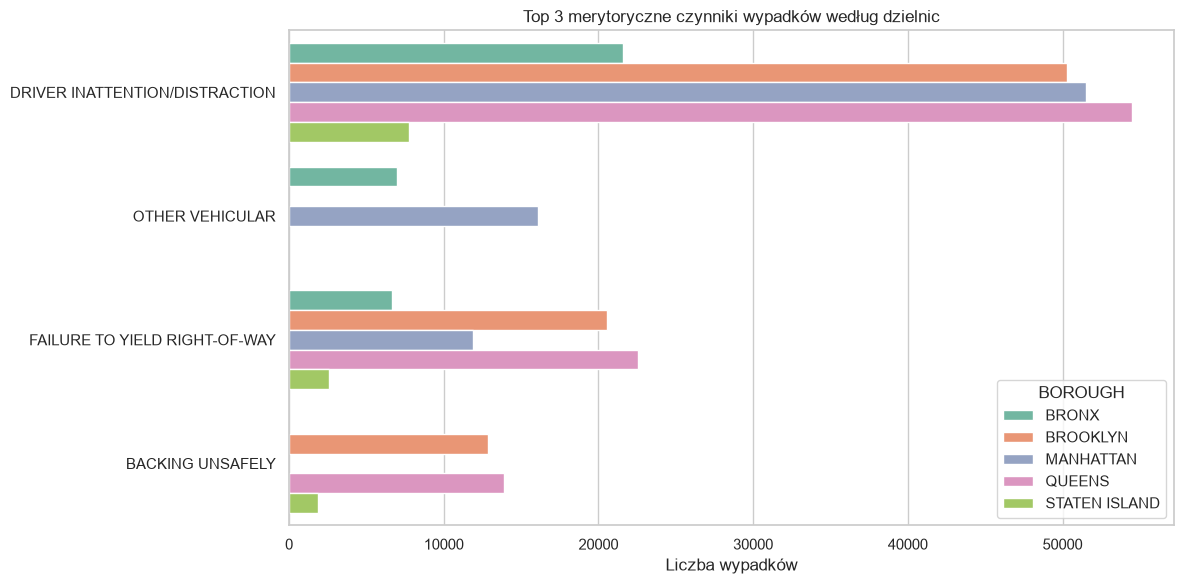

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=borough_real_top3,
    x="liczba_wypadkow",
    y="CONTRIBUTING FACTOR",
    hue="BOROUGH",
    ax=ax,
)
ax.set_title("Top 3 merytoryczne czynniki wypadków według dzielnic")
ax.set_xlabel("Liczba wypadków")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Wniosek do punktu 3.4

W całym zbiorze bardzo często występuje `UNSPECIFIED` - **989 132** wypadki. To oznacza, że w wielu rekordach nie podano dokładnej przyczyny.

Po pominięciu `UNSPECIFIED` najczęstszym czynnikiem jest **DRIVER INATTENTION/DISTRACTION**, czyli nieuwaga lub rozproszenie kierowcy. Ten czynnik wystąpił przy **243 427** wypadkach.


## 3.5. Typy pojazdów najczęściej uczestniczące w wypadkach

Tutaj liczę wystąpienia pojazdów. Jeden wypadek może mieć więcej niż jeden pojazd, więc korzystam z pliku pomocniczego.


Top typy pojazdów - wszystkie kategorie:


,VEHICLE TYPE,liczba_pojazdow
0,PASSENGER VEHICLE,985765
1,SPORT UTILITY / STATION WAGON,646961
2,SEDAN,233277
3,UNKNOWN/OTHER,118951
4,TAXI,98130
5,PICK-UP TRUCK,55105
6,VAN,44135
7,BICYCLE,33962
8,BUS,32616
9,SMALL COM VEH(4 TIRES),22343


Top typy pojazdów - bez UNKNOWN/OTHER:


,VEHICLE TYPE,liczba_pojazdow
0,PASSENGER VEHICLE,985765
1,SPORT UTILITY / STATION WAGON,646961
2,SEDAN,233277
3,TAXI,98130
4,PICK-UP TRUCK,55105
5,VAN,44135
6,BICYCLE,33962
7,BUS,32616
8,SMALL COM VEH(4 TIRES),22343
9,LARGE COM VEH(6 OR MORE TIRES),21093


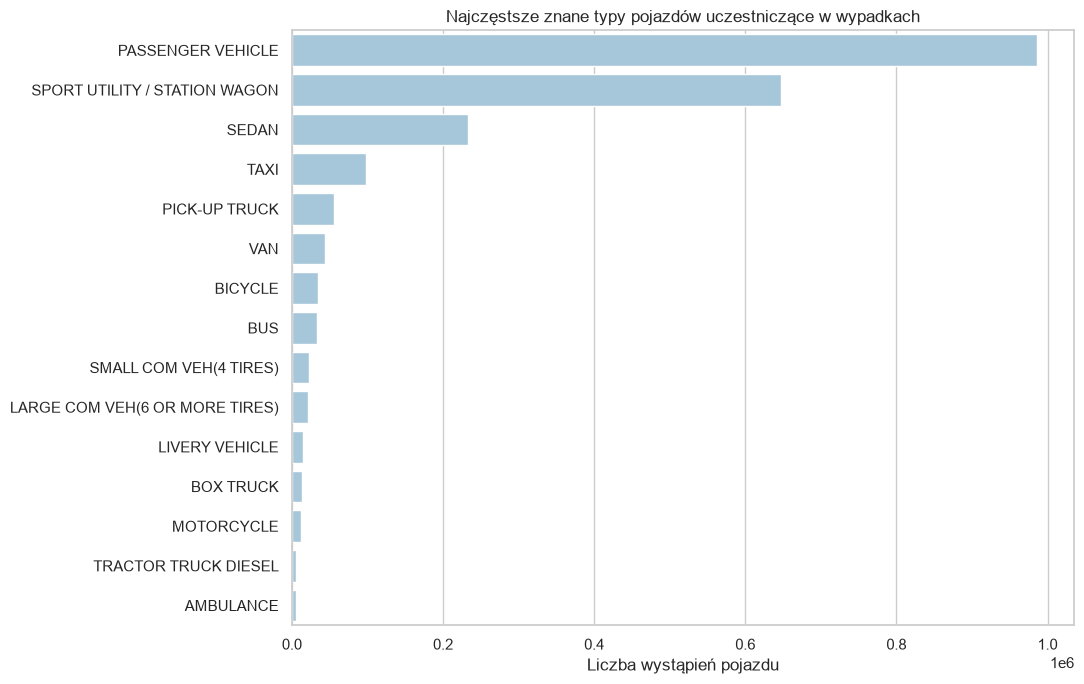

In [11]:
vehicle_counts_all: pd.DataFrame = vehicle_rows["VEHICLE TYPE"].value_counts().rename_axis("VEHICLE TYPE").reset_index(name="liczba_pojazdow")
vehicle_counts_known: pd.DataFrame = known_vehicle_rows["VEHICLE TYPE"].value_counts().rename_axis("VEHICLE TYPE").reset_index(name="liczba_pojazdow")

print("Top typy pojazdów - wszystkie kategorie:")
display(vehicle_counts_all.head(15))
print("Top typy pojazdów - bez UNKNOWN/OTHER:")
display(vehicle_counts_known.head(15))

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=vehicle_counts_known.head(15), x="liczba_pojazdow", y="VEHICLE TYPE", ax=ax, color="#9ECAE1")
ax.set_title("Najczęstsze znane typy pojazdów uczestniczące w wypadkach")
ax.set_xlabel("Liczba wystąpień pojazdu")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Wniosek do punktu 3.5

Najczęściej występującym typem pojazdu jest **PASSENGER VEHICLE** - **985 765** wystąpień. Bardzo często pojawiają się też `SPORT UTILITY / STATION WAGON` oraz `SEDAN`.

Na wykresie nie pokazuję `UNKNOWN/OTHER`, bo to nie jest konkretny typ pojazdu, tylko wartość pomocnicza po czyszczeniu.


## 3.6. Zestawienie liczby wypadków dla każdej dzielnicy

W tym punkcie liczę liczbę wypadków w każdej dzielnicy. Rekordy bez dzielnicy nie są brane do tego porównania.


,liczba_wypadkow,udzial_%
BOROUGH,,
BROOKLYN,291947,31.042538
QUEENS,250082,26.591059
MANHATTAN,228495,24.295727
BRONX,130659,13.892888
STATEN ISLAND,39291,4.177787


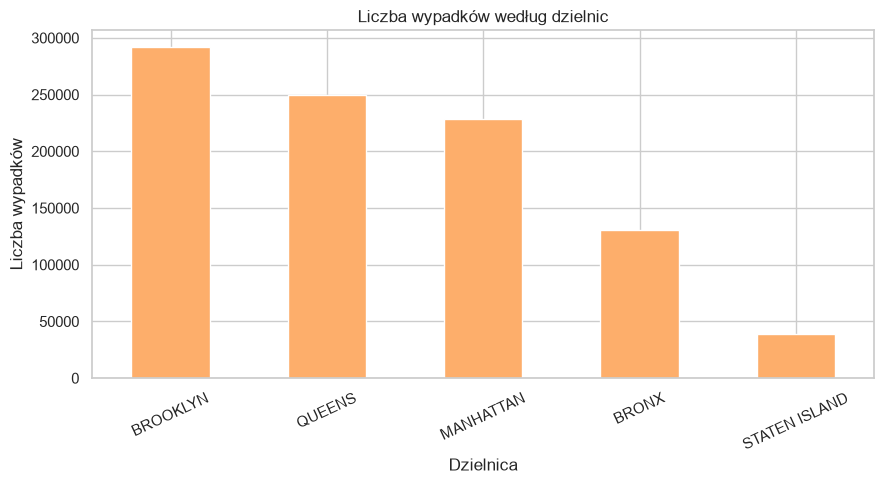

In [12]:
borough_counts: pd.DataFrame = (
    accidents_borough.groupby("BOROUGH")["COLLISION_ID"]
    .nunique()
    .reindex(BOROUGHS)
    .sort_values(ascending=False)
    .rename("liczba_wypadkow")
    .to_frame()
)
borough_counts["udzial_%"] = borough_counts["liczba_wypadkow"] / borough_counts["liczba_wypadkow"].sum() * 100

display(borough_counts)

fig, ax = plt.subplots(figsize=(9, 5))
borough_counts["liczba_wypadkow"].plot(kind="bar", ax=ax, color="#FDAE6B")
ax.set_title("Liczba wypadków według dzielnic")
ax.set_xlabel("Dzielnica")
ax.set_ylabel("Liczba wypadków")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


### Wniosek do punktu 3.6

Najwięcej wypadków było w dzielnicy **BROOKLYN**: **291 947**. To około **31,0%** wypadków, dla których znamy dzielnicę.


## 3.7. Najczęstsze miejsca wystąpień wypadków

Miejsca sprawdzam po współrzędnych. Dodatkowo pokazuję mapę z najczęstszymi punktami, bez używania GeoJSON.


,LATITUDE,LONGITUDE,BOROUGH,miejsce_opisowe,liczba_wypadkow,ranni,zabici
222151,40.798256,-73.827440,NaN,BRONX WHITESTONE BRIDGE,377,233,1
25736,40.608757,-74.038086,NaN,VERRAZANO BRIDGE UPPER,355,181,0
126205,40.704422,-73.994910,BROOKLYN,BROOKLYN BRIDGE,313,82,0
194237,40.757232,-73.989792,MANHATTAN,WEST 42 STREET / 8 AVENUE,290,38,0
230740,40.816864,-73.882744,BRONX,772 EDGEWATER ROAD,272,10,0
114374,40.696035,-73.984529,BROOKLYN,TILLARY STREET / FLATBUSH AVENUE EXTENSION,255,26,0
199078,40.760601,-73.964314,MANHATTAN,EAST 59 STREET / 2 AVENUE,246,28,0
221358,40.795220,-73.921524,NaN,TRIBOROUGH BRIDGE,233,64,0
224386,40.804700,-73.912430,NaN,BRUCKNER BOULEVARD / EAST 138 STREET,223,64,0
244442,40.838010,-73.873290,NaN,BRONX RIVER PARKWAY,222,69,0


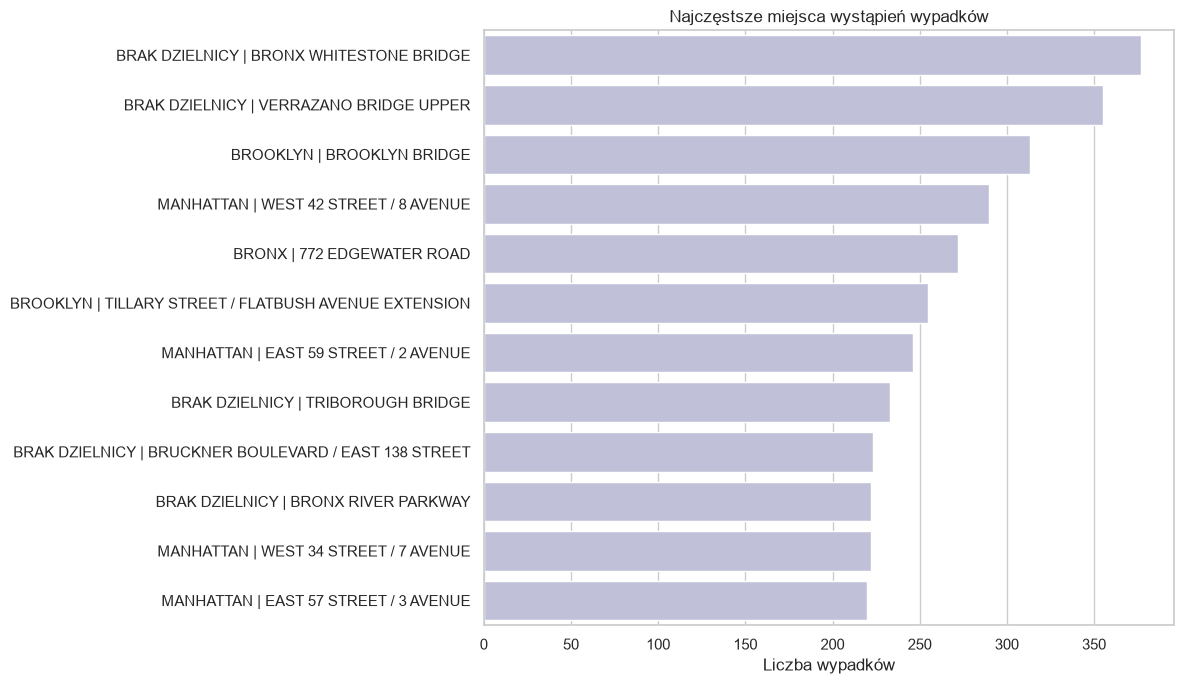

In [13]:
valid_locations: pd.DataFrame = accidents.loc[~accidents["brak_wspolrzednych"]].copy()
location_summary: pd.DataFrame = (
    valid_locations.groupby(["LATITUDE", "LONGITUDE", "BOROUGH", "miejsce_opisowe"], dropna=False)
    .agg(
        liczba_wypadkow=("COLLISION_ID", "nunique"),
        ranni=("NUMBER OF PERSONS INJURED", "sum"),
        zabici=("NUMBER OF PERSONS KILLED", "sum"),
    )
    .reset_index()
    .sort_values("liczba_wypadkow", ascending=False)
)

top_locations: pd.DataFrame = location_summary.head(20)
display(top_locations)

fig, ax = plt.subplots(figsize=(12, 7))
plot_data: pd.DataFrame = top_locations.head(12).copy()
plot_data["etykieta"] = plot_data["BOROUGH"].fillna("BRAK DZIELNICY") + " | " + plot_data["miejsce_opisowe"].str.slice(0, 50)
sns.barplot(data=plot_data, x="liczba_wypadkow", y="etykieta", ax=ax, color="#BCBDDC")
ax.set_title("Najczęstsze miejsca wystąpień wypadków")
ax.set_xlabel("Liczba wypadków")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [14]:
map_locations: pd.DataFrame = location_summary.dropna(subset=["LATITUDE", "LONGITUDE"]).head(50).copy()

accident_map: folium.Map = folium.Map(location=[40.7128, -74.0060], zoom_start=10)

for _, row in map_locations.iterrows():
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=max(4, min(15, row["liczba_wypadkow"] / 30)),
        tooltip=f"{row['miejsce_opisowe']} - {int(row['liczba_wypadkow'])} wypadków",
        color="blue",
        fill=True,
        fill_opacity=0.5,
    ).add_to(accident_map)

accident_map


### Wniosek do punktu 3.7

Najczęściej powtarzającym się miejscem jest **BRONX WHITESTONE BRIDGE** przy współrzędnych **(40.798256, -73.827440)**. W tym miejscu odnotowano **377** wypadków.

Trzeba pamiętać, że jest to analiza punktów po dokładnych współrzędnych, a nie całych ulic.


## 3.8. Wnioski

Na końcu zbieram najważniejsze obserwacje z całej analizy.


### Najważniejsze wnioski końcowe

1. Po czyszczeniu zostało **1 217 634** unikalnych wypadków.
2. Najwięcej wypadków z przypisaną dzielnicą było w **BROOKLYN**: **291 947**.
3. Najczęstszy konkretny czynnik wypadków to **DRIVER INATTENTION/DISTRACTION**.
4. Najczęściej występujący typ pojazdu to **PASSENGER VEHICLE**.
5. Dla czynnika **UNSAFE SPEED** najwięcej rannych i zabitych było w **BROOKLYN**: **1 793** rannych i **21** zabitych.
6. Najczęściej powtarzające się miejsce to **BRONX WHITESTONE BRIDGE**.
7. Wyniki trzeba interpretować ostrożnie, bo dane nie mówią jednoznacznie, kto był sprawcą wypadku.
